In [7]:
# ============================================================
# 셀 1 - 라이브러리 임포트 및 경로 설정
# 학습된 best_model.pth를 불러와서
# threshold 설정 및 탐지 테스트를 진행합니다.
# ============================================================

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import json
from pathlib import Path
from torchvision import transforms
from transformers import ViTModel
from PIL import Image
from torch.utils.data import Dataset, DataLoader

BASE_DIR  = Path(r"C:\Users\user\Desktop\deepfake-detector")
FRAME_DIR = BASE_DIR / "data" / "real_frames"
MODEL_DIR = BASE_DIR / "models" / "occ"

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

Device: cuda


In [8]:
# ============================================================
# 셀 2 - 모델 구조 재정의 및 best_model.pth 로드
# 12_train_occ.ipynb와 동일한 구조를 그대로 사용합니다.
# ============================================================

class ViTAutoEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.vit = ViTModel.from_pretrained("google/vit-base-patch16-224-in21k")
        self.encoder_dim = 768
        self.decoder = nn.Sequential(
            nn.Linear(self.encoder_dim, 512),
            nn.ReLU(),
            nn.Linear(512, 768),
            nn.Tanh()
        )

    def forward(self, x):
        outputs = self.vit(pixel_values=x)
        patch_embeddings = outputs.last_hidden_state[:, 1:, :]  # (B, 196, 768)
        reconstructed_patches = self.decoder(patch_embeddings)   # (B, 196, 768)
        B = x.shape[0]
        patches = reconstructed_patches.view(B, 14, 14, 16, 16, 3)
        patches = patches.permute(0, 5, 1, 3, 2, 4)
        image = patches.contiguous().view(B, 3, 224, 224)
        return image

model = ViTAutoEncoder()
model.load_state_dict(torch.load(MODEL_DIR / "best_model.pth", map_location=DEVICE))
model = model.to(DEVICE)
model.eval()
print("모델 로드 완료")

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

모델 로드 완료


In [9]:
# ============================================================
# 셀 3 - val 데이터셋 로드
# 학습 때와 동일한 방식으로 real 프레임을 불러옵니다.
# val 데이터의 reconstruction error 분포로 threshold를 정합니다.
# ============================================================

from sklearn.model_selection import train_test_split

all_frames = (
    list((FRAME_DIR / "documentary").glob("*.jpg")) +
    list((FRAME_DIR / "vlog").glob("*.jpg"))
)

_, val_frames = train_test_split(all_frames, test_size=0.1, random_state=42)
print(f"val 프레임 수: {len(val_frames)}장")

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])

class RealFrameDataset(Dataset):
    def __init__(self, frame_paths, transform=None):
        self.frame_paths = frame_paths
        self.transform = transform

    def __len__(self):
        return len(self.frame_paths)

    def __getitem__(self, idx):
        img = Image.open(self.frame_paths[idx]).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img

val_dataset = RealFrameDataset(val_frames, transform=transform)
val_loader  = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=0)
print(f"val 배치 수: {len(val_loader)}")

val 프레임 수: 8607장
val 배치 수: 269


In [10]:
# ============================================================
# 셀 4 - val(real) 데이터 reconstruction error 계산
# 각 이미지마다 MSE(입력 vs 복원)를 계산해서 리스트로 저장합니다.
# 이 분포를 기반으로 threshold를 설정합니다.
# ============================================================

criterion = nn.MSELoss(reduction="none")
real_errors = []

with torch.no_grad():
    for batch_idx, imgs in enumerate(val_loader):
        imgs = imgs.to(DEVICE)
        reconstructed = model(imgs)

        # 이미지별 MSE 계산 (배치 평균 아님)
        error = criterion(reconstructed, imgs)
        error = error.mean(dim=[1, 2, 3])  # (B,) — 이미지별 MSE
        real_errors.extend(error.cpu().numpy().tolist())

        if (batch_idx + 1) % 20 == 0:
            print(f"  배치 [{batch_idx+1}/{len(val_loader)}] 완료")

real_errors = np.array(real_errors)
print(f"\nval real 샘플 수: {len(real_errors)}")
print(f"mean:  {real_errors.mean():.6f}")
print(f"std:   {real_errors.std():.6f}")
print(f"min:   {real_errors.min():.6f}")
print(f"max:   {real_errors.max():.6f}")

  배치 [20/269] 완료
  배치 [40/269] 완료
  배치 [60/269] 완료
  배치 [80/269] 완료
  배치 [100/269] 완료
  배치 [120/269] 완료
  배치 [140/269] 완료
  배치 [160/269] 완료
  배치 [180/269] 완료
  배치 [200/269] 완료
  배치 [220/269] 완료
  배치 [240/269] 완료
  배치 [260/269] 완료

val real 샘플 수: 8607
mean:  0.000435
std:   0.000431
min:   0.000005
max:   0.006935


mean + 2×std threshold: 0.001297
mean + 3×std threshold: 0.001728

real 데이터 오탐율 (2std): 4.54%
real 데이터 오탐율 (3std): 1.77%


C:\Users\user\AppData\Local\Temp\ipykernel_5176\3114220602.py:44: UserWarning: Glyph 45936 (\N{HANGUL SYLLABLE DE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_5176\3114220602.py:44: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_5176\3114220602.py:44: UserWarning: Glyph 53552 (\N{HANGUL SYLLABLE TEO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_5176\3114220602.py:44: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_5176\3114220602.py:44: UserWarning: Glyph 54252 (\N{HANGUL SYLLABLE PO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_5176\3114220602.py:44: UserWarning: Glyph 47196 (\N{HANGUL SYLLABLE RO}) missing from font(s) DejaVu 

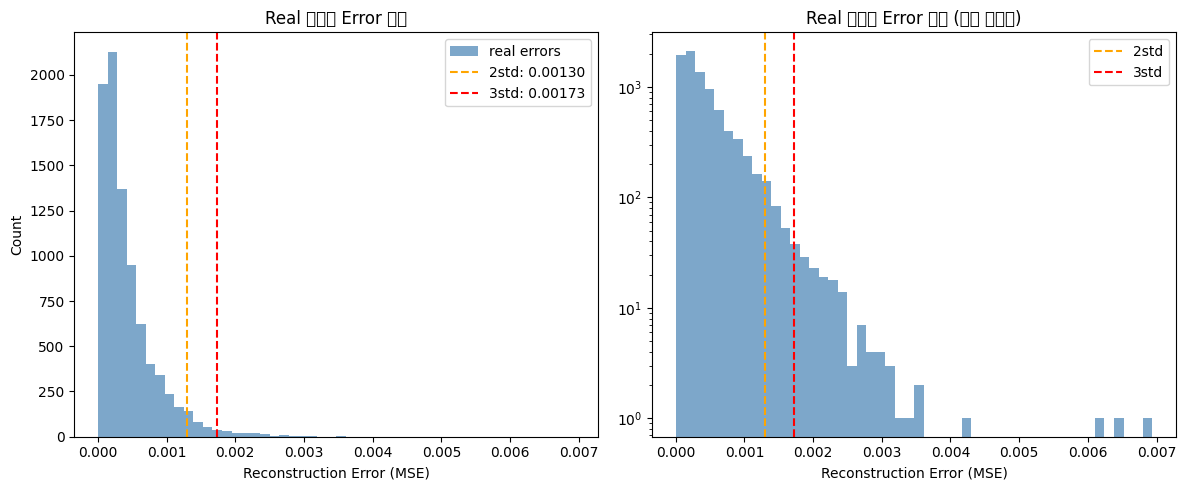

In [11]:
# ============================================================
# 셀 5 - threshold 설정 및 시각화
# 평균 + N×표준편차 방식으로 threshold를 설정합니다.
# N=2: 더 민감 (fake 탐지율 높지만 오탐 가능)
# N=3: 더 보수적 (오탐 낮지만 일부 fake 놓칠 수 있음)
# ============================================================

mean_err = real_errors.mean()
std_err  = real_errors.std()

threshold_2std = mean_err + 2 * std_err
threshold_3std = mean_err + 3 * std_err

print(f"mean + 2×std threshold: {threshold_2std:.6f}")
print(f"mean + 3×std threshold: {threshold_3std:.6f}")

# val real 데이터 기준 오탐율 확인
fp_2std = (real_errors > threshold_2std).mean() * 100
fp_3std = (real_errors > threshold_3std).mean() * 100
print(f"\nreal 데이터 오탐율 (2std): {fp_2std:.2f}%")
print(f"real 데이터 오탐율 (3std): {fp_3std:.2f}%")

# 분포 시각화
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(real_errors, bins=50, color="steelblue", alpha=0.7, label="real errors")
plt.axvline(threshold_2std, color="orange", linestyle="--", label=f"2std: {threshold_2std:.5f}")
plt.axvline(threshold_3std, color="red",    linestyle="--", label=f"3std: {threshold_3std:.5f}")
plt.xlabel("Reconstruction Error (MSE)")
plt.ylabel("Count")
plt.title("Real 데이터 Error 분포")
plt.legend()

plt.subplot(1, 2, 2)
plt.hist(real_errors, bins=50, color="steelblue", alpha=0.7)
plt.axvline(threshold_2std, color="orange", linestyle="--", label=f"2std")
plt.axvline(threshold_3std, color="red",    linestyle="--", label=f"3std")
plt.xlabel("Reconstruction Error (MSE)")
plt.title("Real 데이터 Error 분포 (로그 스케일)")
plt.yscale("log")
plt.legend()

plt.tight_layout()
plt.savefig(str(MODEL_DIR / "threshold_distribution.png"))
plt.show()

In [12]:
# ============================================================
# threshold 재조정 셀
# 현재 2std(0.00130)보다 낮은 값으로 테스트해봅니다.
# val real 데이터 기준 오탐율도 같이 확인합니다.
# ============================================================

candidates = {
    "mean + 1.0std": mean_err + 1.0 * std_err,
    "mean + 1.5std": mean_err + 1.5 * std_err,
    "mean + 2.0std": mean_err + 2.0 * std_err,  # 현재
    "mean + 2.5std": mean_err + 2.5 * std_err,
    "mean + 3.0std": mean_err + 3.0 * std_err,
}

print("threshold별 real 오탐율 비교:")
print("-" * 45)
for name, thr in candidates.items():
    fp = (real_errors > thr).mean() * 100
    current = " ← 현재" if name == "mean + 2.0std" else ""
    print(f"{name}: {thr:.6f} | 오탐율: {fp:.2f}%{current}")

threshold별 real 오탐율 비교:
---------------------------------------------
mean + 1.0std: 0.000866 | 오탐율: 12.76%
mean + 1.5std: 0.001082 | 오탐율: 7.66%
mean + 2.0std: 0.001297 | 오탐율: 4.54% ← 현재
mean + 2.5std: 0.001513 | 오탐율: 2.74%
mean + 3.0std: 0.001728 | 오탐율: 1.77%


In [13]:
# ============================================================
# 셀 6 - threshold 저장
# 나중에 inference 코드에서 불러다 쓸 수 있게
# threshold 값을 JSON으로 저장합니다.
# ============================================================

threshold_data = {
    "mean": float(mean_err),
    "std":  float(std_err),
    "threshold_2std": float(threshold_2std),
    "threshold_3std": float(threshold_3std),
}

threshold_path = MODEL_DIR / "threshold.json"
with open(threshold_path, "w") as f:
    json.dump(threshold_data, f, indent=2)

print(f"threshold 저장 완료: {threshold_path}")
print(json.dumps(threshold_data, indent=2))

threshold 저장 완료: C:\Users\user\Desktop\deepfake-detector\models\occ\threshold.json
{
  "mean": 0.0004350038432084904,
  "std": 0.0004310668862420694,
  "threshold_2std": 0.0012971376156926291,
  "threshold_3std": 0.0017282045019346986
}
